In [5]:
!apt-get install graphviz
!pip install graphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-9ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.


In [1]:
import os
import time
import graphviz
from google.colab import drive

drive.mount('/content/drive')

OUTPUT_DIR = '/content/drive/MyDrive/Colab Notebooks/Trabalho_AEDS_II/Trie'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Pasta de destino pronta em: {OUTPUT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Pasta de destino pronta em: /content/drive/MyDrive/Colab Notebooks/Trabalho_AEDS_II/Trie


In [8]:
class TrieNode:
    def __init__(self):
        self.children = {}
        self.is_end_of_word = False

class TrieInstrumentada:
    def __init__(self):
        self.root = TrieNode()
        self.comparisons_count = 0
        self.nodes_count = 1

    def reset_metrics(self):
        self.comparisons_count = 0

    def insert(self, word: str) -> None:
        node = self.root
        for char in word:
            self.comparisons_count += 1
            if char not in node.children:
                node.children[char] = TrieNode()
                self.nodes_count += 1
            node = node.children[char]
        node.is_end_of_word = True

    def search(self, word: str) -> bool:
        node = self.root
        for char in word:
            self.comparisons_count += 1
            if char not in node.children:
                return False
            node = node.children[char]
        return node.is_end_of_word

    def delete(self, word: str) -> bool:
        def _delete(node, word, depth):
            if depth == len(word):
                if not node.is_end_of_word:
                    return False
                node.is_end_of_word = False
                return len(node.children) == 0

            char = word[depth]
            self.comparisons_count += 1
            if char not in node.children:
                return False

            should_delete_child = _delete(node.children[char], word, depth + 1)

            if should_delete_child:
                del node.children[char]
                self.nodes_count -= 1
                return len(node.children) == 0 and not node.is_end_of_word

            return False

        return _delete(self.root, word, 0)

    def save_diagram(self, filename: str, directory: str = OUTPUT_DIR):
        dot = graphviz.Digraph(comment='Trie')

        def _add_nodes(node, parent_id="root"):
            for char, child in node.children.items():
                child_id = str(id(child))
                color = "green" if child.is_end_of_word else "black"
                shape = "doublecircle" if child.is_end_of_word else "circle"
                dot.node(child_id, label=char, color=color, shape=shape)
                dot.edge(parent_id, child_id)
                _add_nodes(child, child_id)

        dot.node("root", "ROOT", shape="box")
        _add_nodes(self.root)

        # Define o caminho completo sem extensão para o render
        full_path = os.path.join(directory, filename)

        # Gera o ficheiro PNG e guarda no diretório alvo sem usar cleanup=True
        filepath = dot.render(filename=full_path, format='png', cleanup=False)
        print(f"Diagrama Trie salvo com sucesso em: {filepath}")

        return dot

Diagrama Trie salvo com sucesso em: /content/drive/MyDrive/Colab Notebooks/Trabalho_AEDS_II/Trie/trie_exemplo_1.png


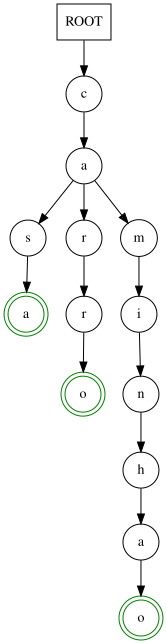

In [9]:

trie = TrieInstrumentada()
trie.insert("casa")
trie.insert("carro")
trie.insert("caminhao")

dot_output = trie.save_diagram("trie_exemplo_1")

dot_output